<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/hidden_input_discretized_pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tempfile
import os

import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [4]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 6s 3ms/step - loss: 0.4356 - accuracy: 0.8864
Epoch 2/40
1563/1563 [==============================] - 4s 3ms/step - loss: 0.2144 - accuracy: 0.9389
Epoch 3/40
1563/1563 [==============================] - 4s 3ms/step - loss: 0.1592 - accuracy: 0.9542
Epoch 4/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1249 - accuracy: 0.9640
Epoch 5/40
1563/1563 [==============================] - 4s 3ms/step - loss: 0.1010 - accuracy: 0.9712
Epoch 6/40
1563/1563 [==============================] - 4s 3ms/step - loss: 0.0835 - accuracy: 0.9762
Epoch 7/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0690 - accuracy: 0.9805
Epoch 8/40
1563/1563 [==============================] - 4s 3ms/step - loss: 0.0581 - accuracy: 0.9844
Epoch 9/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0495 - accuracy: 0.9870
Epoch 10/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.041

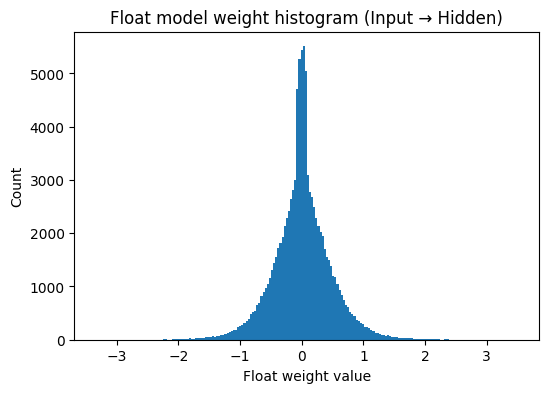

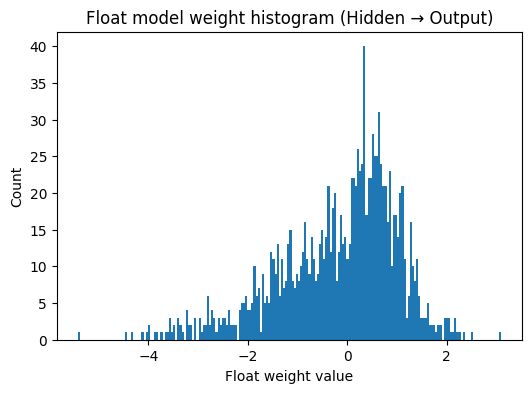

In [6]:
import matplotlib.pyplot as plt

dense_layers = []

for layer in float_model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w2 = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

In [7]:
print("******** Non discretized weights for hidden to input layer ************ \n\n")

layer_weights2, biases2 = dense_layers[1].get_weights()
print(layer_weights2)
#weights only for one layer

******** Non discretized weights for hidden to input layer ************ 


[[ 0.566492   -0.58908194 -1.4759327  ... -1.0684966   0.6925098
   0.5901894 ]
 [ 0.02500261  0.62874913 -0.39466545 ... -2.1721585   0.6975172
  -0.99902403]
 [ 1.511998    0.57732105 -1.8482289  ...  0.764001    0.6901076
   0.58437175]
 ...
 [-1.8757502  -0.32526958 -1.4888638  ...  0.33776152  1.2651079
  -0.15563367]
 [-1.2772787   1.2632086   0.5047969  ... -1.9736716  -1.5289162
   1.3250202 ]
 [ 0.3206194  -0.5653669   0.66178876 ...  0.3279974  -1.1390722
   0.07672099]]


In [8]:
levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels2 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped


In [9]:
snapped_weights2 = snap_weights_to_levels(layer_weights2, levels2)

In [10]:
print("\n\n")
print(snapped_weights2)




[[ 0.75 -0.75 -1.   ... -1.    0.75  0.75]
 [ 0.    0.75 -0.25 ... -1.    0.75 -1.  ]
 [ 1.    0.75 -1.   ...  0.75  0.75  0.75]
 ...
 [-1.   -0.25 -1.   ...  0.25  1.   -0.25]
 [-1.    1.    0.75 ... -1.   -1.    1.  ]
 [ 0.25 -0.75  0.75 ...  0.25 -1.    0.  ]]


In [11]:
dense_layers[1].set_weights([snapped_weights2, biases2])

In [12]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.1584 - accuracy: 0.9587
Accuracy: 0.9587000012397766


In [13]:
float_history = float_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1563/1563 [==============================] - 4s 3ms/step - loss: 0.0046 - accuracy: 0.9996
Epoch 2/5
1563/1563 [==============================] - 4s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 3/5
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0013 - accuracy: 1.0000
Epoch 4/5
1563/1563 [==============================] - 4s 3ms/step - loss: 0.0010 - accuracy: 1.0000
Epoch 5/5
1563/1563 [==============================] - 4s 3ms/step - loss: 7.8206e-04 - accuracy: 1.0000


In [14]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0984 - accuracy: 0.9758
Accuracy: 0.9757999777793884


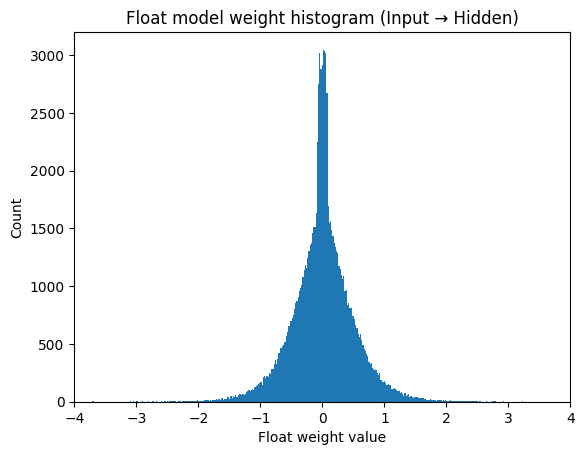

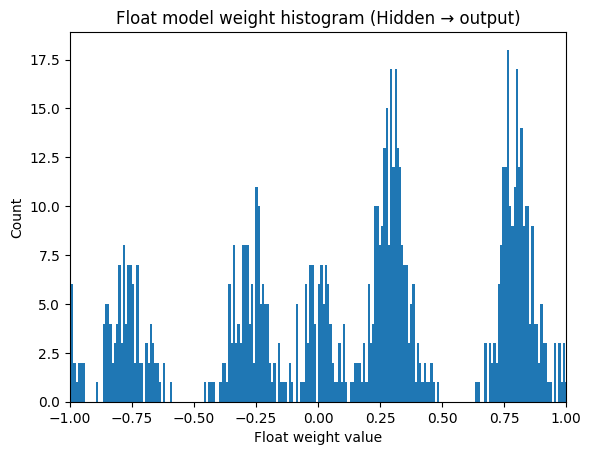

In [15]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)
w2 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-4, 4])
plt.show()

plt.hist(w2, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → output)")
plt.xlim([-1, 1])
plt.show()

Input to hiddem is discretized only